# ***lumin***
  A modular image processing toolkit that applies classical and AI-based techniques for tasks like denoising, color correction, edge detection, and compression.



In [ ]:
# dependencies
import pandas as pd
import numpy as np
# form glob import glob
import glob
import cv2
import matplotlib.pyplot as plt

##  **Images** Operation

In [15]:
lu1 = glob.glob('/content/lumin_1.png')
lu2 = glob.glob('/content/lumin_2.png')
lu3 = glob.glob('/content/lumin_3.png')
lu4 = glob.glob('/content/lumin_4.png')
lu5 = glob.glob('/content/lumin_5.png')
lu6 = glob.glob('/content/lumin_6.png')
lu7 = glob.glob('/content/lumin_7.png')
lu8 = glob.glob('/content/lumin_8.png')
lu9 = glob.glob('/content/lumin_9.png')
lu10 = glob.glob('/content/lumin_10.png')
lu1_area = glob.glob('/content/lumin_Area-covered.png')
lu1_pol = glob.glob('/content/lumin_polygon.png')


In [18]:
image_paths = [
    '/content/lumin_1.png',
    '/content/lumin_2.png',
    '/content/lumin_3.png',
    '/content/lumin_4.png',
    '/content/lumin_5.png',
    '/content/lumin_6.png',
    '/content/lumin_7.png',
    '/content/lumin_8.png',
    '/content/lumin_9.png',
    '/content/lumin_10.png',
    '/content/lumin_Area-covered.png',
    '/content/lumin_polygon.png'
]

image_data = {}
for path in image_paths:
    image_name = path.split('/')[-1].split('.')[0] # Extract image name without path and extension
    try:
        image_data[image_name] = plt.imread(path)
        print(f"Successfully read image: {image_name}")
    except FileNotFoundError:
        print(f"Error: Image not found at {path}")

Successfully read image: lumin_1
Successfully read image: lumin_2
Successfully read image: lumin_3
Successfully read image: lumin_4
Successfully read image: lumin_5
Successfully read image: lumin_6
Successfully read image: lumin_7
Successfully read image: lumin_8
Successfully read image: lumin_9
Successfully read image: lumin_10
Successfully read image: lumin_Area-covered
Successfully read image: lumin_polygon


In [22]:
# np type datatype and shape
type(image_data['lumin_1'])
image_data['lumin_1'].shape

(628, 1450, 4)

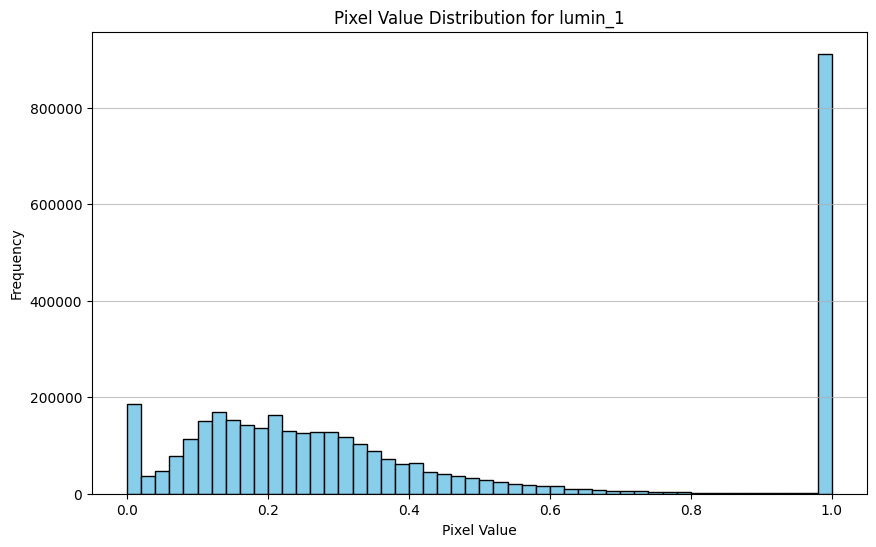

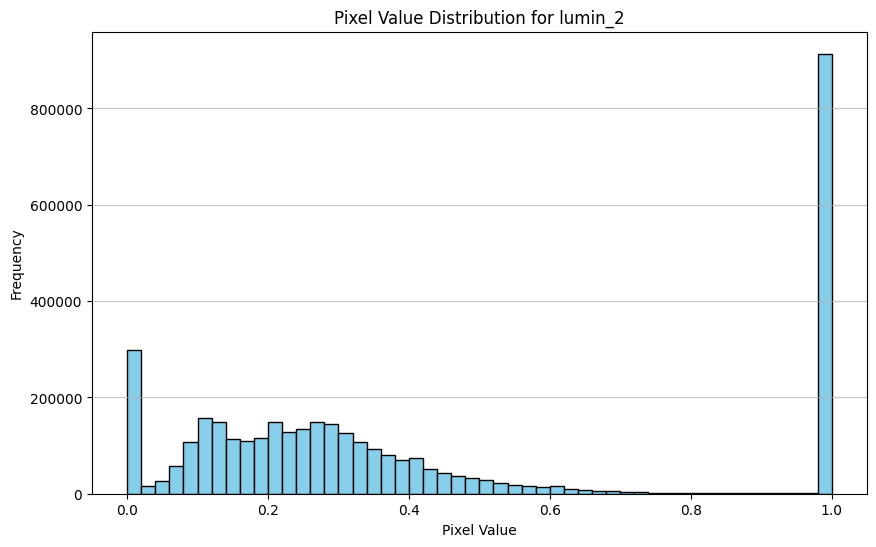

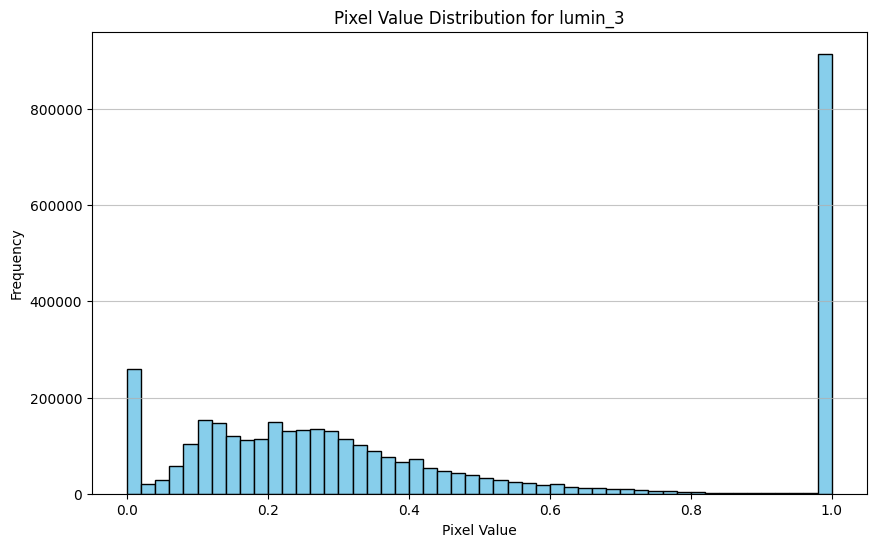

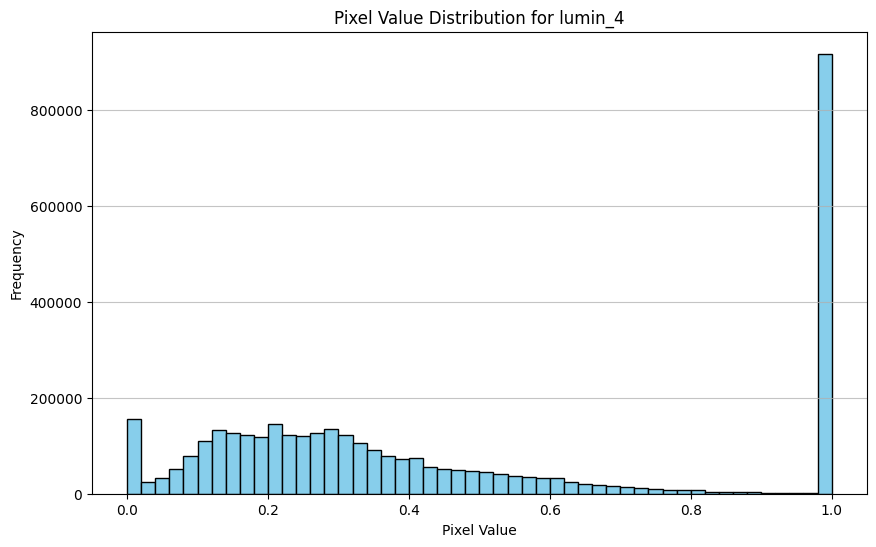

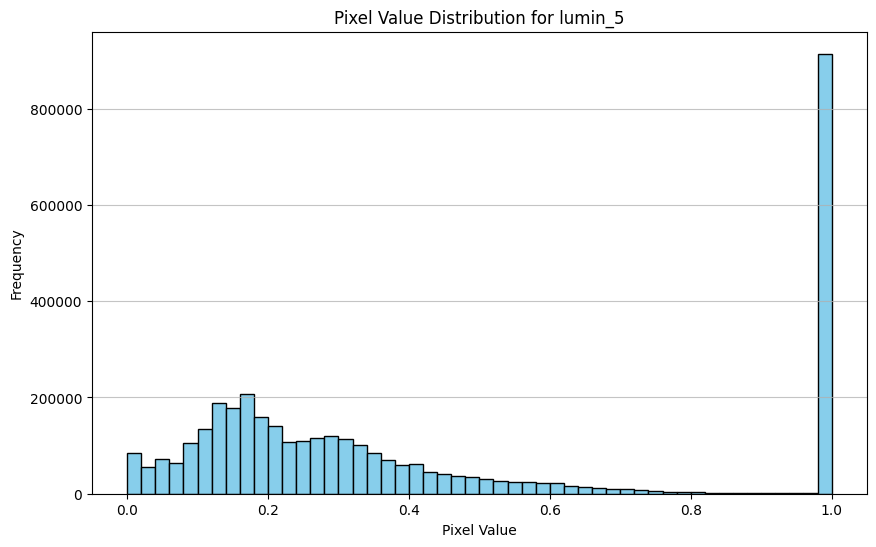

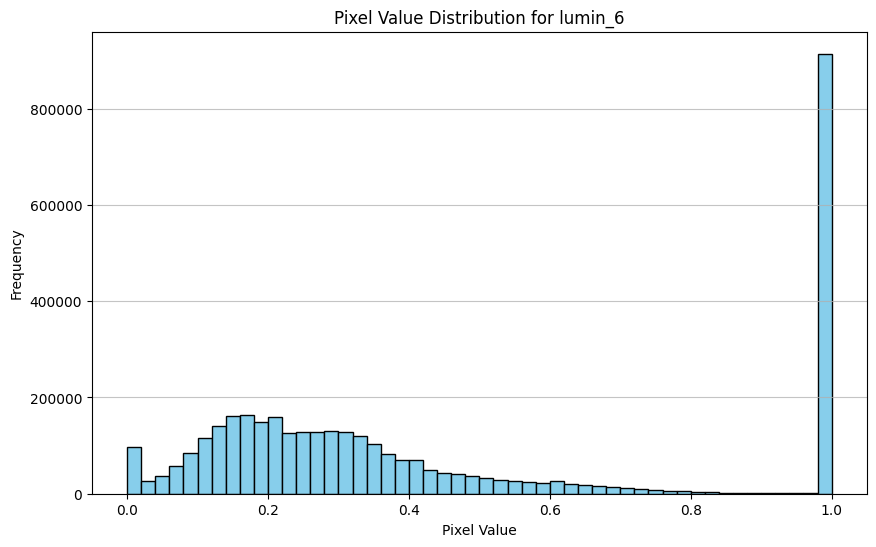

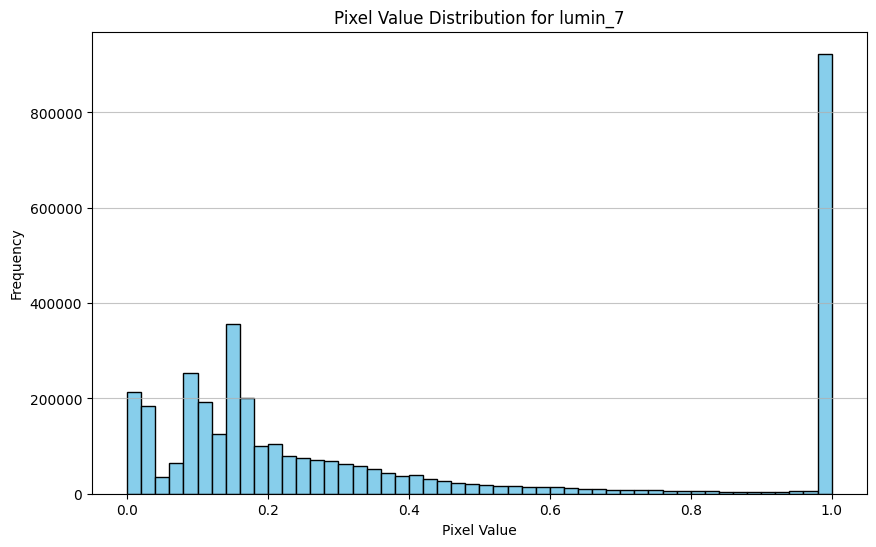

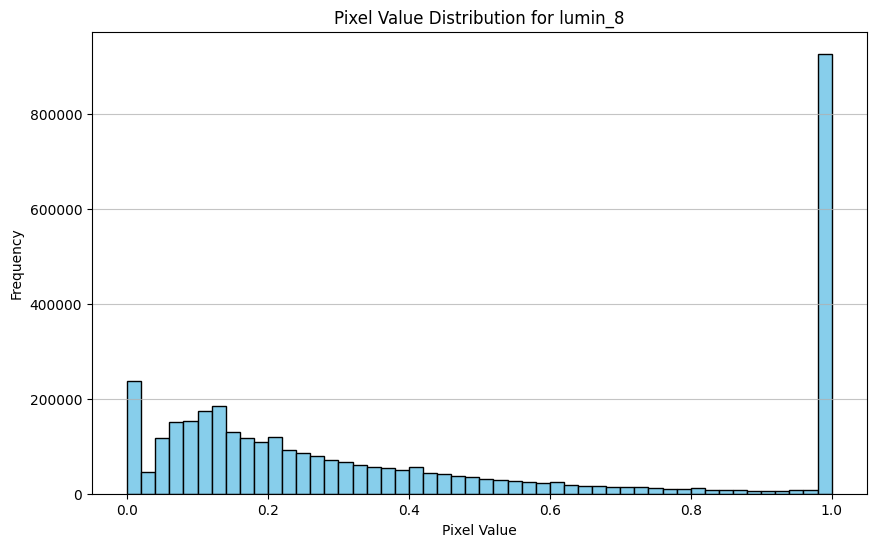

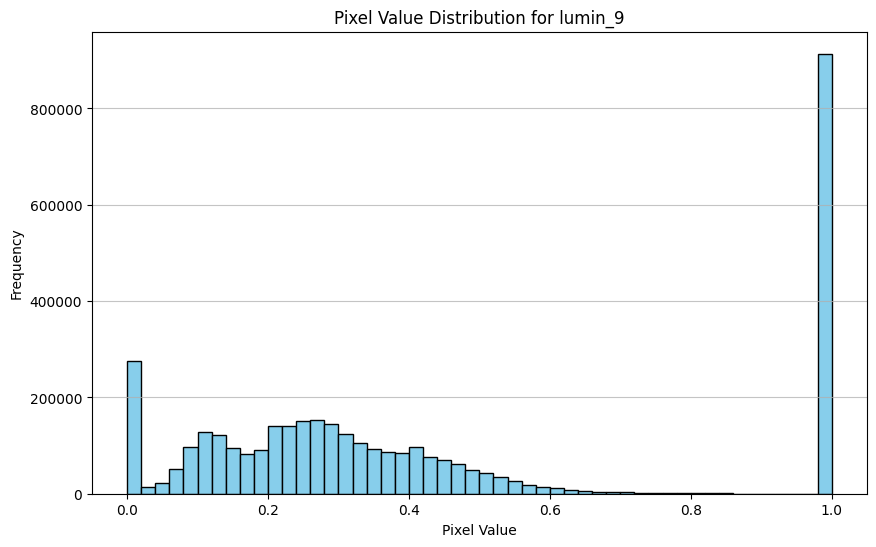

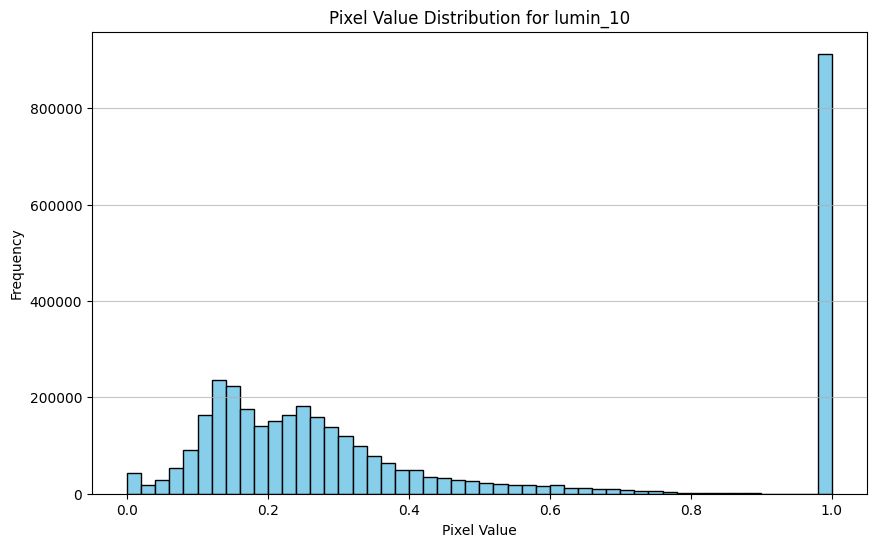

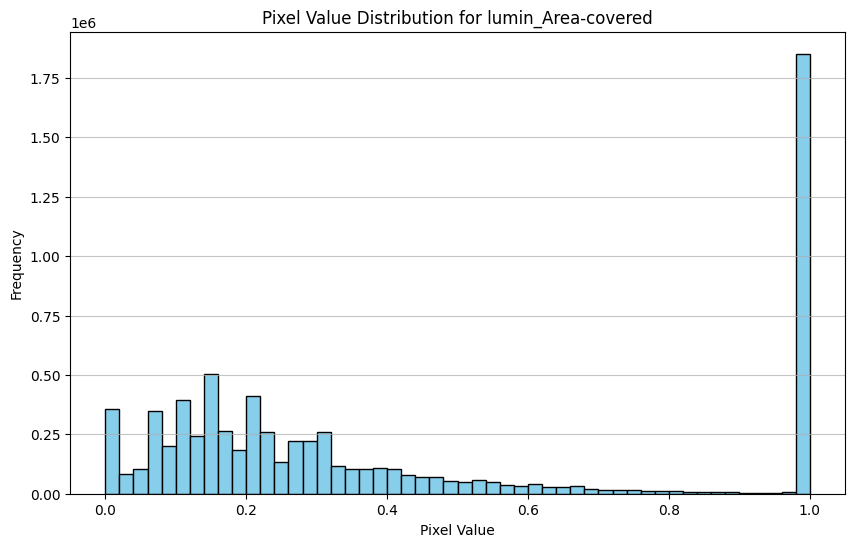

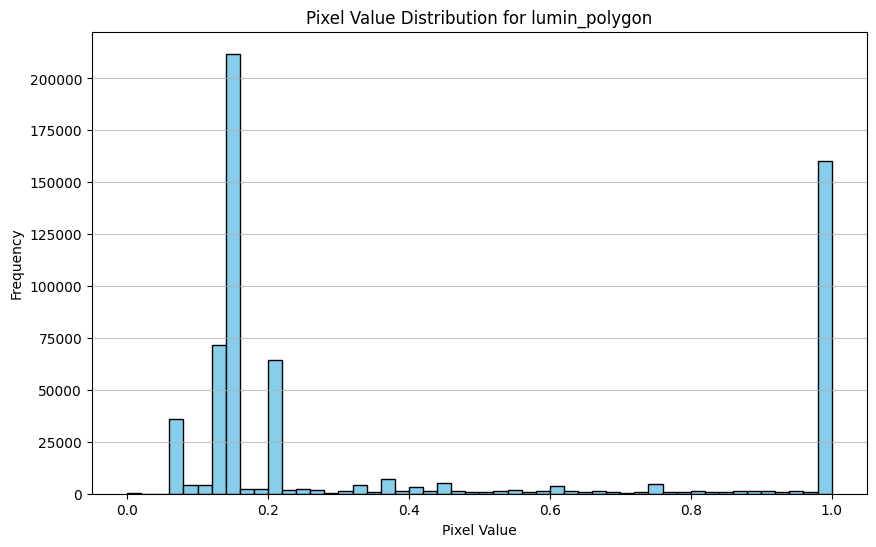

In [25]:
# distribution of pixel value for each img
for image_name, image_array in image_data.items():
    # Flatten the image array to get a 1D array of pixel values
    flattened_pixels = image_array.flatten()

    # Plot a histogram of the pixel values
    plt.figure(figsize=(10, 6))
    plt.hist(flattened_pixels, bins=50, color='skyblue', edgecolor='black')
    plt.title(f'Pixel Value Distribution for {image_name}')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [33]:
# display img
for image_name, image_array in image_data.items():
    plt.figure(figsize=(8, 8))
    plt.imshow(image_array)
    plt.title(f'Image: {image_name}')
    plt.axis('off') # hide the axes
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

## **Matplotlib** vs **cv2** diff. channels reads

In [42]:
## Show how to apply this comparison to all images in your image_data dictionary (or a similar structure for cv2)

cv2_image_data = {}

for path in image_paths:
    image_name = path.split('/')[-1].split('.')[0] # Extract image name
    try:
        # cv2.imread reads images in BGR format by default
        cv2_image_data[image_name] = cv2.imread(path)
        print(f"Successfully read image with cv2: {image_name}")
    except cv2.error as e:
        print(f"Error reading image with cv2 at {path}: {e}")


# Iterate through the keys present in both dictionaries and 5. print shape and data type
print("\nComparison of Image Data:")
for image_name in image_data.keys(): # Assuming image_data contains all image names from image_paths
    if image_name in cv2_image_data:
        mpl_array = image_data[image_name]
        cv2_array = cv2_image_data[image_name]

        print(f"\nImage: {image_name}")
        print(f"  Matplotlib - Shape: {mpl_array.shape}, Data type: {mpl_array.dtype}")
        print(f"  CV2        - Shape: {cv2_array.shape}, Data type: {cv2_array.dtype}")

#  Optionally, select a small pixel region and print values for a couple of images
print("\nComparison of Pixel Values (Selected Images):")
images_to_compare_pixels = ['lumin_1', 'lumin_Area-covered'] # Choose a couple of images

for image_name in images_to_compare_pixels:
    if image_name in image_data and image_name in cv2_image_data:
        mpl_array = image_data[image_name]
        cv2_array = cv2_image_data[image_name]

        # Select a small region (adjust coordinates if necessary based on image size)
        # Ensure the region is within the bounds of the image
        h, w = mpl_array.shape[:2]
        row_start, row_end = min(10, h), min(12, h)
        col_start, col_end = min(20, w), min(22, w)


        mpl_region = mpl_array[row_start:row_end, col_start:col_end]
        cv2_region = cv2_array[row_start:row_end, col_start:col_end]

        print(f"\nImage: {image_name}")
        print("  Matplotlib region pixel values:")
        print(mpl_region)
        print("  CV2 region pixel values:")
        print(cv2_region)

Successfully read image with cv2: lumin_1
Successfully read image with cv2: lumin_2
Successfully read image with cv2: lumin_3
Successfully read image with cv2: lumin_4
Successfully read image with cv2: lumin_5
Successfully read image with cv2: lumin_6
Successfully read image with cv2: lumin_7
Successfully read image with cv2: lumin_8
Successfully read image with cv2: lumin_9
Successfully read image with cv2: lumin_10
Successfully read image with cv2: lumin_Area-covered
Successfully read image with cv2: lumin_polygon

Comparison of Image Data:

Image: lumin_1
  Matplotlib - Shape: (628, 1450, 4), Data type: float32
  CV2        - Shape: (628, 1450, 3), Data type: uint8

Image: lumin_2
  Matplotlib - Shape: (629, 1451, 4), Data type: float32
  CV2        - Shape: (629, 1451, 3), Data type: uint8

Image: lumin_3
  Matplotlib - Shape: (629, 1451, 4), Data type: float32
  CV2        - Shape: (629, 1451, 3), Data type: uint8

Image: lumin_4
  Matplotlib - Shape: (629, 1451, 4), Data type: fl

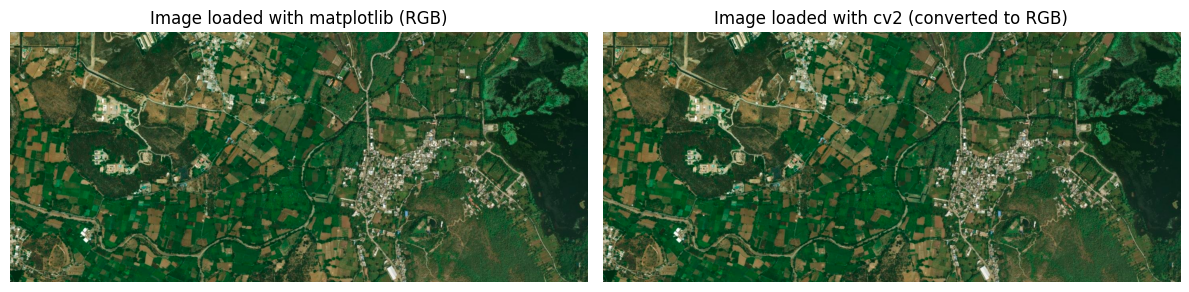

In [43]:
# visual comparision
sample_image_path = image_paths[0]

# Load the image using matplotlib (RGB)
mpl_image = plt.imread(sample_image_path)

# Load the image using cv2 (BGR)
cv2_image_bgr = cv2.imread(sample_image_path)

# Convert the cv2 image from BGR to RGB for correct display with matplotlib
cv2_image_rgb = cv2.cvtColor(cv2_image_bgr, cv2.COLOR_BGR2RGB)

# Display the images side by side
plt.figure(figsize=(12, 6))

# Display the matplotlib image
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.imshow(mpl_image)
plt.title('Image loaded with matplotlib (RGB)')
plt.axis('off')

# Display the cv2 image (after converting to RGB)
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.imshow(cv2_image_rgb)
plt.title('Image loaded with cv2 (converted to RGB)')
plt.axis('off')

plt.tight_layout() # Adjust layout to prevent titles overlapping
plt.show()

## **Image** Sharpening

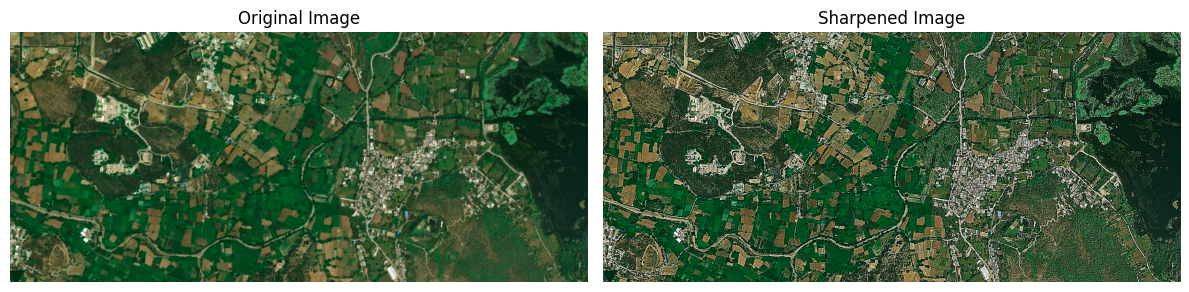

In [45]:
#choose an image to sharpen (e.g., 'lumin_1')
image_to_sharpen_name = 'lumin_1'

if image_to_sharpen_name in cv2_image_data:
    # get the image in BGR format from cv2_image_data
    original_image_bgr = cv2_image_data[image_to_sharpen_name]

    # define the sharpening kernel
    # this is a common kernel for sharpening
    sharpening_kernel = np.array([[-1, -1, -1],
                                  [-1, 9, -1],
                                  [-1, -1, -1]])

    # apply the sharpening filter using cv2.filter2D
    sharpened_image_bgr = cv2.filter2D(original_image_bgr, -1, sharpening_kernel)

    # convert images to RGB for displaying with matplotlib
    original_image_rgb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2RGB)
    sharpened_image_rgb = cv2.cvtColor(sharpened_image_bgr, cv2.COLOR_BGR2RGB)

    # display the original and sharpened images side by side
    plt.figure(figsize=(12, 6))

    # display the original image
    plt.subplot(1, 2, 1)
    plt.imshow(original_image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    # display the sharpened image
    plt.subplot(1, 2, 2)
    plt.imshow(sharpened_image_rgb)
    plt.title('Sharpened Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

else:
    print(f"Image '{image_to_sharpen_name}' not found in cv2_image_data.")

#maintainstail





### Subtask:
Define the color ranges (e.g., in RGB or HSV color space) that correspond to water, trees, and houses. This might require some experimentation to find appropriate ranges for your specific images.


In [56]:
# convert a sample image to HSV to help define color ranges
# using lumin_1 as a sample
sample_image_rgb = image_data['lumin_1']
# convert float32 (0-1 range) RGB to uint8 (0-255 range) BGR for cv2
sample_image_bgr_uint8 = (sample_image_rgb[:, :, :3] * 255).astype(np.uint8)
sample_image_hsv = cv2.cvtColor(sample_image_bgr_uint8, cv2.COLOR_BGR2HSV)

# define color ranges in HSV
# these ranges might need adjustment based on experimentation
lower_blue = np.array([100, 50, 50])    # lower bound for blue (water)
upper_blue = np.array([140, 255, 255])  # upper bound for blue (water)

lower_green = np.array([35, 50, 50])   # lower bound for green (trees)
upper_green = np.array([85, 255, 255]) # upper bound for green (trees)

# white color range can be tricky in HSV, often defined by high Value and low Saturation
lower_white = np.array([0, 0, 150])    # lower bound for white (houses) - low S, high V
upper_white = np.array([180, 50, 255]) # upper bound for white (houses) - low S, high V

print("Color ranges defined in HSV:")
print(f"Blue (Water): Lower={lower_blue}, Upper={upper_blue}")
print(f"Green (Trees): Lower={lower_green}, Upper={upper_green}")
print(f"White (Houses): Lower={lower_white}, Upper={upper_white}")

Color ranges defined in HSV:
Blue (Water): Lower=[100  50  50], Upper=[140 255 255]
Green (Trees): Lower=[35 50 50], Upper=[ 85 255 255]
White (Houses): Lower=[  0   0 150], Upper=[180  50 255]


## Process each image



In [57]:
# create a list of image names to process (lumin_1 to lumin_10)
selected_image_names = [f'lumin_{i}' for i in range(1, 11)]

# iterate through the selected images
for image_name in selected_image_names:
    if image_name in image_data:
        image_array = image_data[image_name]
        print(f"Processing image: {image_name}")
        # further processing for classification will go here in subsequent steps
    else:
        print(f"Image '{image_name}' not found in image_data.")


Processing image: lumin_1
Processing image: lumin_2
Processing image: lumin_3
Processing image: lumin_4
Processing image: lumin_5
Processing image: lumin_6
Processing image: lumin_7
Processing image: lumin_8
Processing image: lumin_9
Processing image: lumin_10


**Reasoning**:
Convert the current image from RGB (matplotlib's format) to BGR (cv2's expected format) and then to HSV, as the color ranges were defined in HSV space.



**Reasoning**:
Apply the HSV color range masks to the current image to identify pixels belonging to water, trees, and houses.



In [59]:
selected_image_names = [f'lumin_{i}' for i in range(1, 11)]

lower_blue = np.array([100, 50, 50])    # lower bound for blue (water)
upper_blue = np.array([140, 255, 255])  # upper bound for blue (water)

lower_green = np.array([35, 50, 50])   # lower bound for green (trees)
upper_green = np.array([85, 255, 255]) # upper bound for green (trees)

# white color range can be tricky in HSV, often defined by high Value and low Saturation
lower_white = np.array([0, 0, 150])    # lower bound for white (houses) - low S, high V
upper_white = np.array([180, 50, 255]) # upper bound for white (houses) - low S, high V

# define color range for yellow (soil) in HSV
lower_yellow = np.array([20, 100, 100]) # lower bound for yellow (soil)
upper_yellow = np.array([30, 255, 255]) # upper bound for yellow (soil)


# iterate through the selected images
classified_images = {} # dictionary to store classified images for later display

for image_name in selected_image_names:
    if image_name in image_data:
        image_array_rgb = image_data[image_name]
        print(f"Processing image: {image_name}")

        # convert image from float32 (0-1) RGB to uint8 (0-255) BGR for cv2
        # check if image has alpha channel (4 channels) and remove it if present
        if image_array_rgb.shape[-1] == 4:
            image_array_rgb_no_alpha = (image_array_rgb[:, :, :3] * 255).astype(np.uint8)
        else:
            image_array_rgb_no_alpha = (image_array_rgb * 255).astype(np.uint8)

        image_array_bgr = cv2.cvtColor(image_array_rgb_no_alpha, cv2.COLOR_RGB2BGR)

        # convert BGR image to HSV
        image_array_hsv = cv2.cvtColor(image_array_bgr, cv2.COLOR_BGR2HSV)

        # create masks for each color
        mask_blue = cv2.inRange(image_array_hsv, lower_blue, upper_blue)
        mask_green = cv2.inRange(image_array_hsv, lower_green, upper_green)
        mask_white = cv2.inRange(image_array_hsv, lower_white, upper_white)
        mask_yellow = cv2.inRange(image_array_hsv, lower_yellow, upper_yellow) # mask for yellow (soil)


        # combine masks to get all classified pixels
        combined_mask = mask_blue | mask_green | mask_white | mask_yellow # include yellow mask


        # create a classified image:
        # start with a black image
        classified_image = np.zeros_like(image_array_rgb_no_alpha)

        # color the pixels based on the masks
        classified_image[mask_blue > 0] = [255, 0, 0]    # blue for water (in RGB)
        classified_image[mask_green > 0] = [0, 128, 0]  # dark Green for trees (in RGB) # Changed to dark green
        classified_image[mask_white > 0] = [255, 255, 255] # white for houses (in RGB)
        classified_image[mask_yellow > 0] = [255, 255, 0] # yellow for soil (in RGB)


        # store the classified image
        classified_images[image_name] = classified_image


    else:
        print(f"Image '{image_name}' not found in image_data.")

Processing image: lumin_1
Processing image: lumin_2
Processing image: lumin_3
Processing image: lumin_4
Processing image: lumin_5
Processing image: lumin_6
Processing image: lumin_7
Processing image: lumin_8
Processing image: lumin_9
Processing image: lumin_10


**Reasoning**:
Display the original and classified images side-by-side for each processed image.



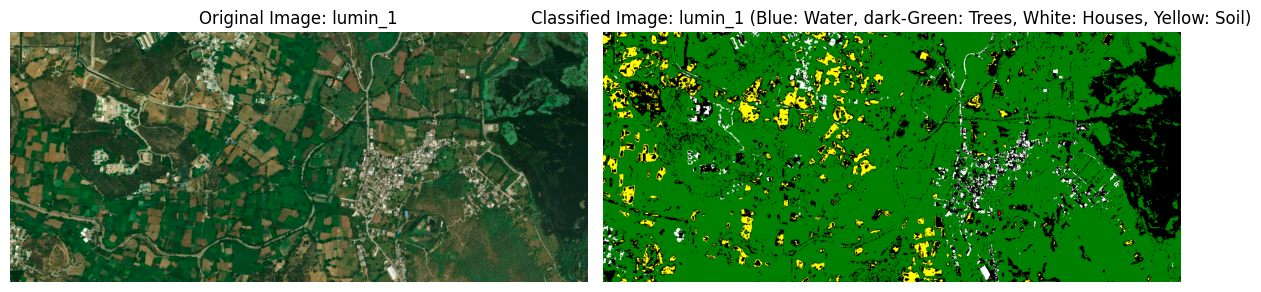

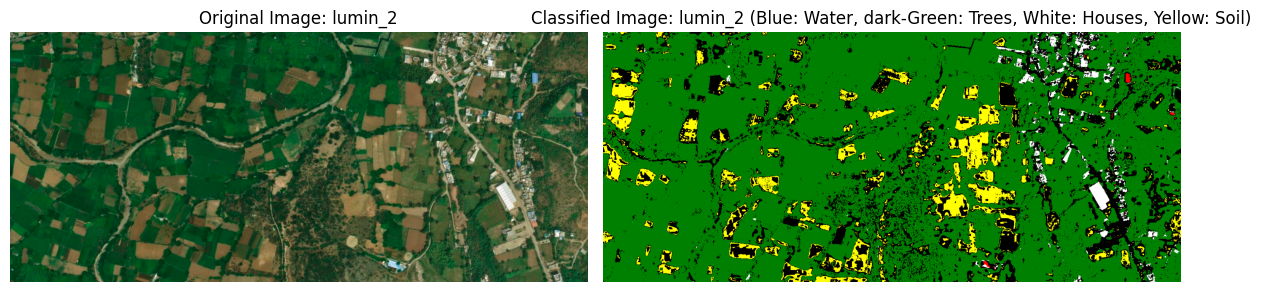

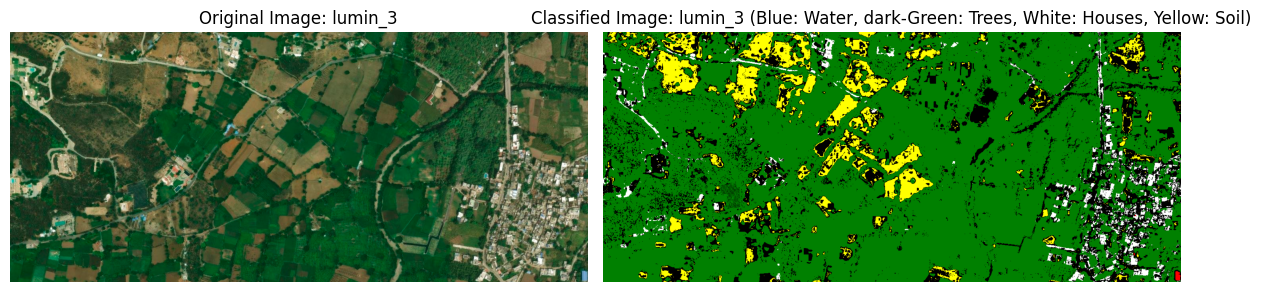

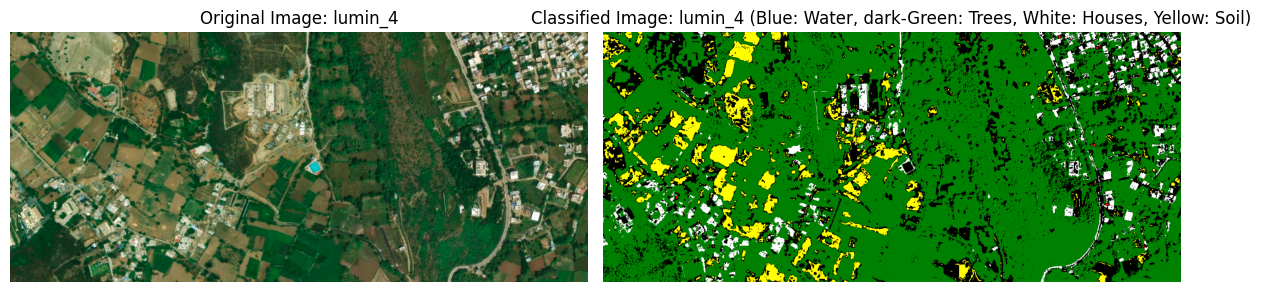

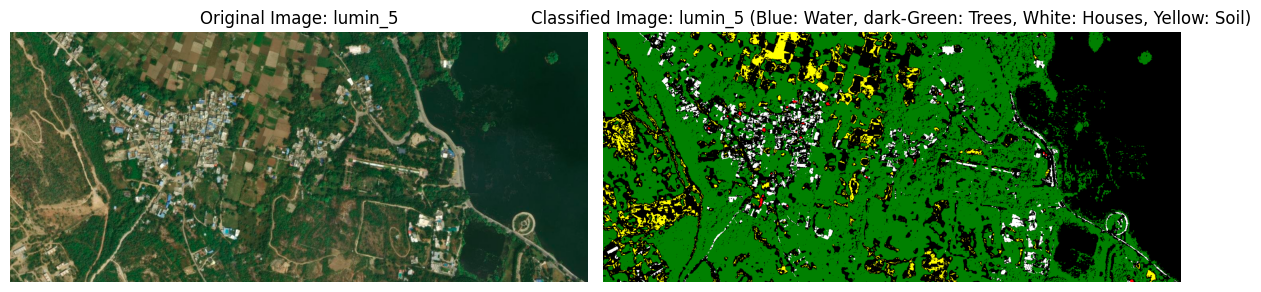

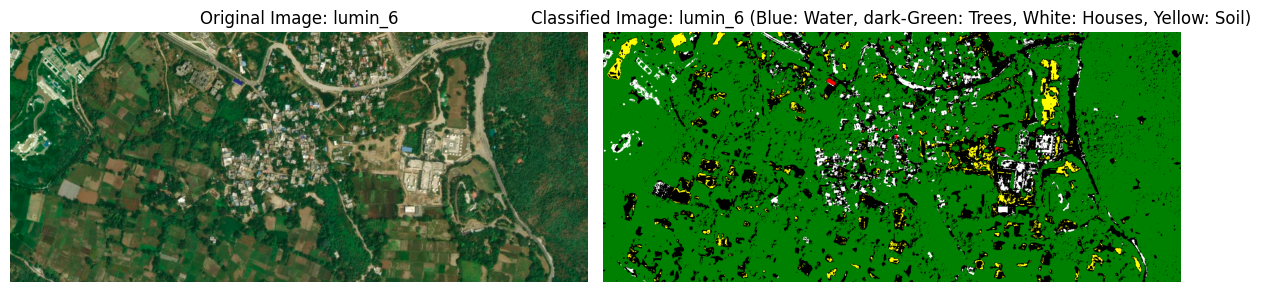

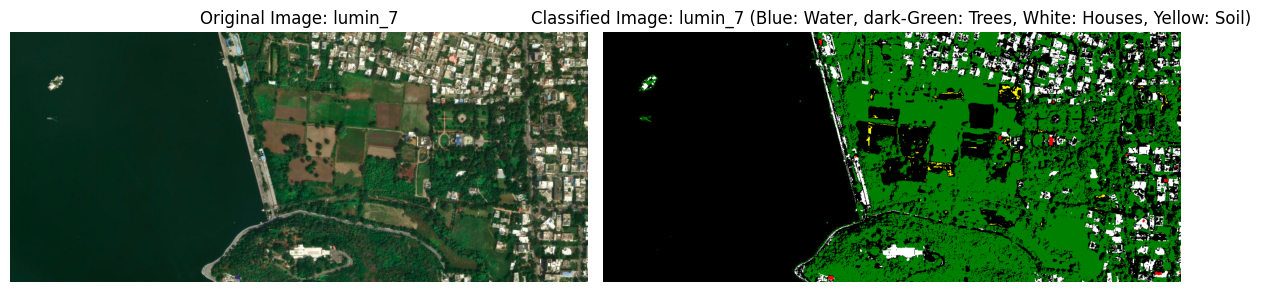

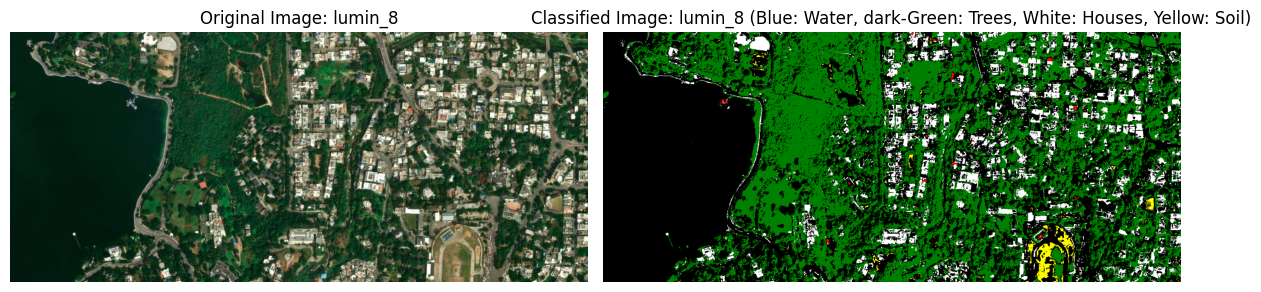

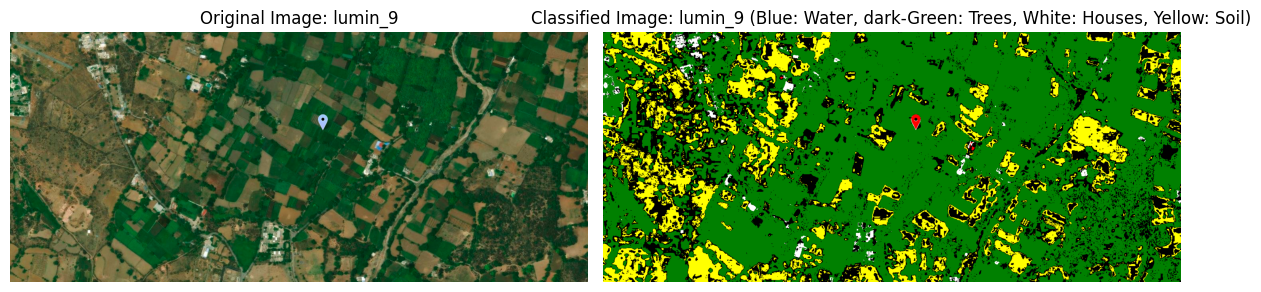

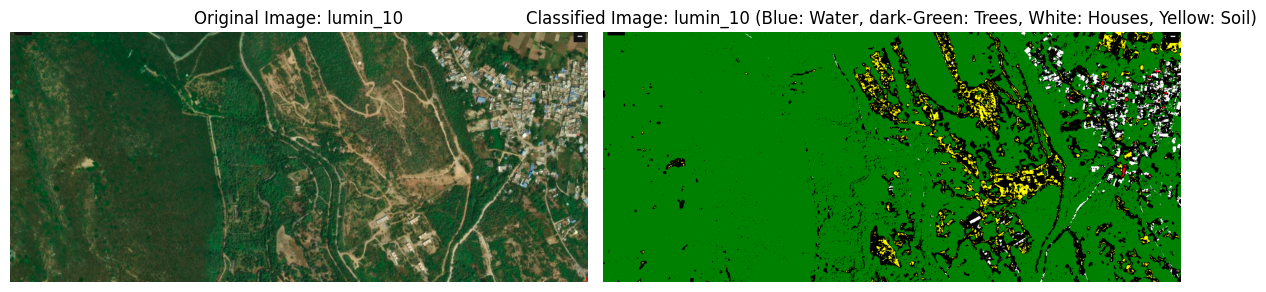

In [61]:
# display the original and classified images side-by-side
for image_name in selected_image_names:
    if image_name in image_data and image_name in classified_images:
        original_image_rgb = image_data[image_name]
        classified_image = classified_images[image_name]

        plt.figure(figsize=(12, 6))

        # display original image
        plt.subplot(1, 2, 1)
        plt.imshow(original_image_rgb)
        plt.title(f'Original Image: {image_name}')
        plt.axis('off')

        # display classified image
        plt.subplot(1, 2, 2)
        plt.imshow(classified_image) # classified image is already in RGB (colored based on masks)
        plt.title(f'Classified Image: {image_name} (Blue: Water, dark-Green: Trees, White: Houses, Yellow: Soil)') # Update title
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Could not display images for {image_name}. Make sure both original and classified images are available.")

## Project Summary

This project focused on building a modular image processing toolkit called ***lumin***. We utilized classical image processing techniques and libraries to perform tasks such as image loading, analysis of pixel value distribution, comparison of different image reading methods, image sharpening, and color-based image classification.

### Architecture and Libraries Used

The project primarily leveraged the following Python libraries:

- **`pandas`**: Used for data manipulation, although its usage was minimal in the final image processing steps.
- **`numpy`**: Fundamental for numerical operations and handling image data as multi-dimensional arrays.
- **`glob`**: Used for finding image files within the file system.
- **`cv2` (OpenCV)**: A powerful library for various image processing tasks, including reading and writing images (in BGR format), color space conversions (like BGR to HSV), and applying filters (like sharpening).
- **`matplotlib.pyplot`**: Used for loading images (in RGB format) and, importantly, for visualizing images and plotting data like pixel value distributions.

The architecture is based on loading image data into NumPy arrays and then applying various operations provided by OpenCV and Matplotlib. The data flow generally involves:

1.  **Loading Images**: Images are loaded from files using both `matplotlib.pyplot.imread` and `cv2.imread`. A dictionary (`image_data`) is used to store the images loaded with `matplotlib`, and another (`cv2_image_data`) for images loaded with `cv2`.
2.  **Initial Analysis**: Basic analysis like checking the shape and data type of the image arrays and visualizing pixel value distributions using histograms were performed.
3.  **Comparison of Libraries**: A comparison was made between `matplotlib` and `cv2` regarding how they read image channels (RGB vs. BGR) and the data types of the resulting arrays.
4.  **Image Sharpening**: A sharpening filter was applied to an image using `cv2.filter2D` with a defined kernel.
5.  **Color-based Classification**: This was a significant task involving:
    *   Defining color ranges for specific categories (water, trees, houses, soil) in the HSV color space.
    *   Converting images to the HSV color space using `cv2.cvtColor`.
    *   Creating binary masks for each color range using `cv2.inRange`.
    *   Creating a new "classified image" by coloring pixels based on the applied masks.
    *   Storing these classified images in a dictionary (`classified_images`).

### Tasks Performed

Throughout this notebook, we accomplished the following key tasks:

-   Loaded multiple images into the notebook environment.
-   Explored the basic properties of the image data (data type and shape).
-   Analyzed the distribution of pixel values across different images.
-   Visually displayed individual images and all images.
-   Compared image loading between `matplotlib` and `cv2`, highlighting the channel order difference (RGB vs. BGR) and data types.
-   Performed image sharpening using a convolution kernel with OpenCV.
-   Implemented a color-based image classification system to identify and visualize areas corresponding to water, trees, houses, and soil.

### Conclusion

The ***lumin*** toolkit, as demonstrated in this notebook, provides a foundation for basic image processing tasks using Python and popular libraries like OpenCV and Matplotlib. We successfully loaded, analyzed, and manipulated image data. The comparison between `matplotlib` and `cv2` highlighted their different approaches to channel order, which is crucial for accurate color-based processing. The implementation of color-based classification showcased how to segment images based on defined color ranges, allowing for the identification of specific features like water bodies, vegetation, buildings, and soil.

This project can be extended by:
- Refining the color ranges for more accurate classification.
- Implementing other image processing techniques (e.g., edge detection, blurring, noise reduction).
- Developing more sophisticated classification methods (e.g., using machine learning).
- Calculating quantitative metrics for the classified areas (e.g., the percentage of area covered by each category).